In [1]:
import pandas as pd
import numpy as np

# Описание полей

- `timestamp` -- дата и время поста 
<br>
- `company` -- название компании
<br>
- `level` -- уровень специалиста (jun - mid - senior etc)
<br>
- `title` -- название вакансии 
<br>
- `totalyearlycompensation` -- годовая заработная плана. в контексте всех последующих задач, именно это поле будет иметься в виду под названием "зарплата"
<br>
- `location` -- город и штат\страна, где работает специалист
<br>
- `yearsofexperience` -- уровень специалиста
<br>
- `yearsatcompany` -- опыт работы специалиста 
<br>
- `basesalary` -- базовая компенсация
<br>



In [2]:
df = pd.read_csv('P01_Salaries_Dataset.csv', index_col = 0)

C:\Users\Aldo\AppData\Local\Temp\ipykernel_17700\400210739.py:1: DtypeWarning: Columns (0: bonus, 1: gender) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('P01_Salaries_Dataset.csv', index_col = 0)


Вам необходимо будет проделать несколько задач по датасету, в удобном для вас формате -- либо используя **методы pandas**, либо **через SQL-код**

# Задачи

1. Сколько уникальных компаний находятся в топ 10 по сумме годовых заработной платы `totalyearlycompensation`?
1. Какой средний опыт работы у `Software Engineers` в компании `Oracle` с заработной платой больше `50.000`?
1. Каковы средние зарплаты по локациям `Austin, TX`, `London, EN, United Kingdom` и `Redmond, WA`
1. Какова средняя зарплата в целом в штате Калифорния? `(CA)`

1. Сравните заработные платы компаний "FAANG" против остальных компаний в разрезе позиции `Software Engineer`

1. Сравните среднюю, медиану и моду по заработным платам у `Software Engineers` за периоды 
  `январь 2021 - апрель 2021`  vs `май 2021 - август 2021` (включительно)
1. Визуализируйте данные с предыдущего задания линейным графиком, где должны быть соблюдены следующие условия:
    - Период январь-апрель должен быть зеленого цвета
    - Период май-август должен быть красного цвета
    - на линейном графике должны присутствовать только средние значения (mean)

1. Оцените влияние уровня образования (или его отсутствия) к заработной плате

1. Оцените _зависимость_ между опытом работы `yearsofexperience` и заработной платой

1. Сделайте сравнение уровня зарплат в зависимости от грэйда (level) в компании Amazon на позицию 'Software Engineer'. Постройте визуализацию и **напишите ваши выводы**. [Подробнее о грэйдах в Amazon](https://careerkarma.com/blog/software-engineering-salary-amazon/), [примеры исследования позиций и зарплат в Казахстане](https://zerttey.kolesa.group/datascience#zp)

# Task 1

In [8]:
df.sort_values("totalyearlycompensation", ascending = False).head(10)['company'].nunique()

6

# Task 2

In [22]:
df[(df['title'] == "Software Engineer") & (df['company'] == "Oracle") & (df['totalyearlycompensation'] > 50000)]['yearsatcompany'].str.replace(',', '.').astype(float).mean()

np.float64(2.379722921914358)

И вариант если нам понадобится целое число

In [23]:
round(df[(df['title'] == "Software Engineer") & (df['company'] == "Oracle") & (df['totalyearlycompensation'] > 50000)]['yearsatcompany'].str.replace(',', '.').astype(float).mean())

2

# Task 3

In [27]:
df[df['location'].isin(['Austin, TX', 'London, EN, United Kingdom', 'Redmond, WA'])]['totalyearlycompensation'].mean()

np.float64(201228.00377617576)

# Task 4

In [32]:
df[df['location'].str.contains('CA')]['totalyearlycompensation'].mean()

np.float64(271834.7212947323)

# Task 5

In [35]:
faang = ['Facebook', 'Amazon', 'Apple', 'Netflix', 'Google']
faang_mean = df[(df['title'] == 'Software Engineer') & (df['company'].isin(faang))]['totalyearlycompensation'].mean()
faang_mean

np.float64(255887.40249609985)

In [36]:
other_mean = df[(df['title'] == 'Software Engineer') & (~df['company'].isin(faang))]['totalyearlycompensation'].mean()
other_mean

np.float64(186222.7254084845)

In [37]:
if(faang_mean > other_mean):
    print('FAANG платит больше')
else:
    print('Другие платят больше')

FAANG платит больше


# Task 6

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=False)

In [ ]:
df_jan_apr = df[
    (df['title'] == 'Software Engineer') & (df['timestamp'] >= '2021-01-01') & (df['timestamp'] <= '2021-04-30')
]
df_may_aug = df[
    (df['title'] == 'Software Engineer') & (df['timestamp'] >= '2021-05-01') & (df['timestamp'] <= '2021-08-31')
]

# Средние

In [12]:
df_jan_apr['totalyearlycompensation'].mean()

np.float64(199110.9127692491)

In [13]:
df_may_aug['totalyearlycompensation'].mean()

np.float64(186914.53712632594)

Январь-апрель > май-август

# Медиана

In [14]:
df_jan_apr['totalyearlycompensation'].median()

np.float64(175000.0)

In [15]:
df_may_aug['totalyearlycompensation'].median()

np.float64(165000.0)

Январь-апрель больше

# Мода

In [16]:
df_jan_apr['totalyearlycompensation'].mode()

0    150000
Name: totalyearlycompensation, dtype: int64

In [17]:
df_may_aug['totalyearlycompensation'].mode()

0    150000
Name: totalyearlycompensation, dtype: int64

Одинаковые

# Task 7

In [18]:
m_mean = df[df['title'] == 'Software Engineer'].groupby(df['timestamp'].dt.to_period('M'))['totalyearlycompensation'].mean()
m_mean

timestamp
2017-06    160222.222222
2017-07    222411.764706
2017-08    256740.740741
2017-09    218115.384615
2017-10    302583.333333
2017-11    205769.230769
2017-12    210380.000000
2018-01    288425.925926
2018-02    267434.782609
2018-03    242333.333333
2018-04    251559.090909
2018-05    235681.537572
2018-06    216104.455446
2018-07    230262.711864
2018-08    228557.692308
2018-09    237187.866928
2018-10    230805.337520
2018-11    217701.461378
2018-12    238119.592875
2019-01    236083.511777
2019-02    222854.932302
2019-03    215669.753086
2019-04    226089.314195
2019-05    233421.921922
2019-06    229577.123050
2019-07    215721.369540
2019-08    213021.683673
2019-09    222020.332717
2019-10    207687.965921
2019-11    203277.180406
2019-12    222624.195624
2020-01    216792.574657
2020-02    211718.750000
2020-03    213759.429154
2020-04    209380.059230
2020-05    208664.970314
2020-06    213899.707887
2020-07    209137.354651
2020-08    195899.672846
2020-09    1947

In [19]:
jan_apr = m_mean['2021-01': '2021-04']
may_aug = m_mean['2021-05': '2021-08']

In [3]:
import matplotlib.pyplot as plt

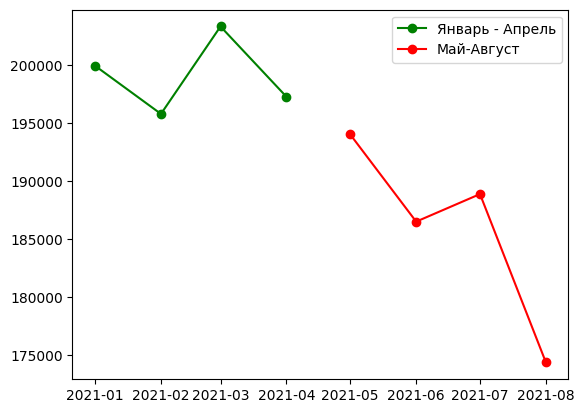

In [21]:
plt.plot(jan_apr.index.to_timestamp(), jan_apr.values, 'go-', label = "Январь - Апрель")
plt.plot(may_aug.index.to_timestamp(),may_aug.values, 'ro-', label = "Май-Август")
plt.legend()
plt.show()


# Task 8

In [9]:
ed_salary = df.groupby('Education')['totalyearlycompensation'].agg(['mean', 'median', 'count']).sort_values(by = 'mean',ascending = False)
ed_salary

,mean,median,count
Education,,,
PhD,292860.465116,255000.0,1892
Master's Degree,220304.590679,195000.0,17187
Some College,210747.524752,172500.0,404
Highschool,187741.573034,162000.0,356
Bachelor's Degree,178092.821606,156000.0,14070


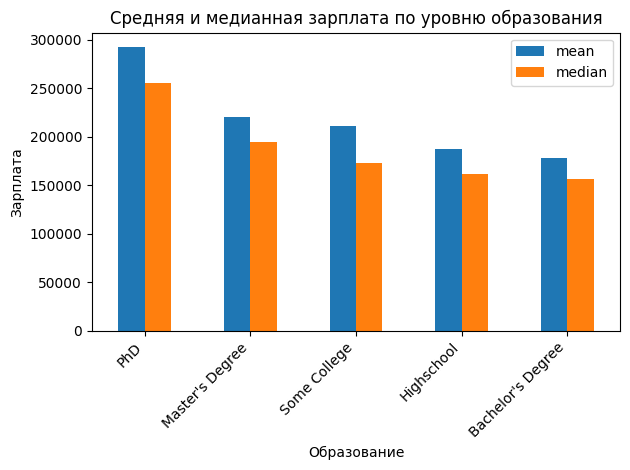

In [10]:
ed_salary[['mean', 'median']].plot(kind='bar')
plt.title('Средняя и медианная зарплата по уровню образования')
plt.xlabel('Образование')
plt.ylabel('Зарплата')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Task 9

In [12]:
df['yearsofexperience'] = pd.to_numeric(df['yearsofexperience'], errors = 'coerce')
correl = df['yearsofexperience'].corr(df['totalyearlycompensation'])
correl

np.float64(0.42396960925287175)

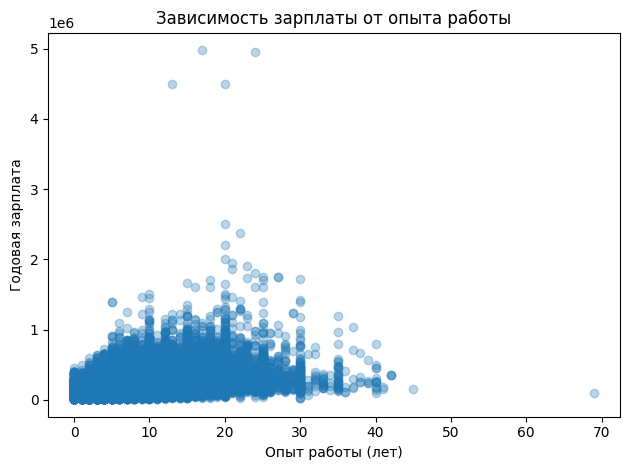

In [18]:
plt.scatter(df['yearsofexperience'], df['totalyearlycompensation'], alpha = 0.3)
plt.title('Зависимость зарплаты от опыта работы')
plt.xlabel('Опыт работы (лет)')
plt.ylabel('Годовая зарплата')
plt.tight_layout()
plt.show()

# Task 10

In [5]:
amazon_se = df[(df['company'] == 'Amazon') & (df['title'] == 'Software Engineer')]
lvl_salary = amazon_se.groupby('level')['totalyearlycompensation'].agg(['mean', 'median', 'count']).sort_values('mean')
lvl_salary

,mean,median,count
level,,,
L4,150054.682590,156000.0,1591
SDE I,151063.714903,156000.0,463
SDE II,209071.588367,210000.0,447
L5,210082.440615,215000.0,2147
L6,304937.823834,300000.0,579
SDE III,305543.689320,300000.0,103


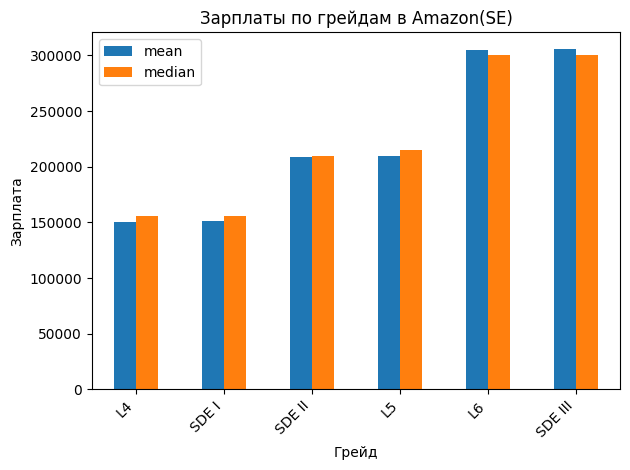

In [6]:
lvl_salary[['mean', 'median']].plot(kind = 'bar')
plt.title('Зарплаты по грейдам в Amazon(SE)')
plt.xlabel('Грейд')
plt.ylabel('Зарплата')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

# Вывод

В датасете есть два типа грейдов - L-система (L4, L5, L6) и SDE-система (SDE I, II, III), которые обозначают одно и то же, просто в разных форматах.
L4/SDE I это джуниор уровень с зарплатой около 150к в год. L5/SDE II это мидл, зарплата вырастает до примерно 210к. L6/SDE III это сеньор, зарплата достигает около 305к.
Каждый следующий грейд дает примерно +40-60% к зарплате. Разрыв между средним и медианой небольшой, что говорит о том, что выбросов почти нет и данные равномерные внутри каждого грейда.
Также выборка по L5 самая большая (2147 записей) - это логично, так как большинство инженеров в Amazon находятся на мидл уровне.